# Customer Churn Prediction - Entrenamiento de Modelos

**Objetivo:**
En este notebook entrenaremos y evaluaremos varios modelos de Machine Learning para predecir la pérdida de clientes (Churn).
Se entrenarán modelos base, se evaluará su rendimiento mediante métricas clave y se compararán los resultados para seleccionar el modelo más prometedor para optimización posterior.

**Modelos a entrenar:**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

Se incluirán visualizaciones de desempeño, matrices de confusión y curvas ROC para cada modelo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)

# Configuración general
sns.set(style='whitegrid')
np.random.seed(42)

In [2]:
#Quitar warnings
import warnings
warnings.filterwarnings('ignore')

## 🔹 Carga de datos preprocesados

En esta sección cargamos los datasets que ya han sido preprocesados en el Notebook 2.
Esto asegura que el Notebook de modelado sea independiente y reproducible.

Variables disponibles:
- `X_train`, `X_test`: features escaladas y codificadas
- `y_train`, `y_test`: variable objetivo binaria


In [3]:
#Usamos las variables ya preprocesadas en el notebook 02
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

## ⚙️ Entrenamiento de modelos base

Entrenaremos cuatro modelos iniciales con **hiperparámetros por defecto**, únicamente para comparar su rendimiento base:

1. **Logistic Regression** – modelo lineal de referencia.
2. **Decision Tree** – modelo interpretable basado en reglas.
3. **Random Forest** – ensamblado de árboles con reducción de varianza.
4. **XGBoost** – modelo de boosting altamente eficiente.

Evaluaremos su rendimiento usando las siguientes métricas:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [4]:
# Inicializamos los modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []

# Asegurar que y_train y y_test sean Series para compatibilidad
y_train_series = pd.Series(y_train)
y_test_series = pd.Series(y_test)

# Detectar si las etiquetas son texto o números
is_text_labels = y_test_series.dtype == 'O'

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Si son etiquetas de texto ("Yes"/"No"), convertir a binario
    if is_text_labels:
        y_true = (y_test_series == 'Yes').astype(int)
        y_pred_binary = (y_pred == 'Yes').astype(int)
    else:
        y_true = y_test_series
        y_pred_binary = y_pred

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred_binary),
        "Precision": precision_score(y_true, y_pred_binary),
        "Recall": recall_score(y_true, y_pred_binary),
        "F1-Score": f1_score(y_true, y_pred_binary),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819,0.836071
3,XGBoost,0.778252,0.589080,0.548128,0.567867,0.819647
2,Random Forest,0.788913,0.627907,0.505348,0.560000,0.814967
1,Decision Tree,0.711443,0.456522,0.449198,0.452830,0.627744


## 📊 Comparación visual de métricas entre modelos

En esta sección visualizamos las métricas de rendimiento principales para comparar los modelos base.
Nos centraremos especialmente en el **F1-Score** (balance entre precisión y recall) y en el **ROC-AUC** (capacidad de discriminación global del modelo).

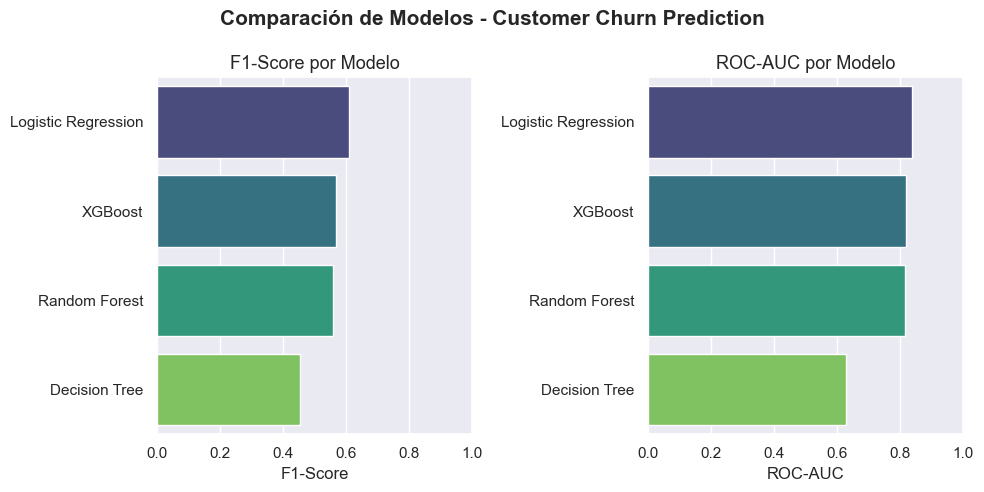

In [5]:
plt.figure(figsize=(10, 5))
metrics_to_plot = ["F1-Score", "ROC-AUC"]

for i, metric in enumerate(metrics_to_plot):
    plt.subplot(1, 2, i + 1)
    sns.barplot(
        data=results_df,
        y="Model", x=metric,
        palette="viridis", order=results_df.sort_values(metric, ascending=False)["Model"]
    )
    plt.title(f"{metric} por Modelo", fontsize=13)
    plt.xlabel(metric)
    plt.ylabel("")
    plt.xlim(0, 1)

plt.suptitle("Comparación de Modelos - Customer Churn Prediction", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧩 Evaluación detallada de los modelos

En esta sección analizamos el desempeño de cada modelo en mayor profundidad mediante:

1. **Matriz de confusión:** muestra cómo se distribuyen las predicciones correctas e incorrectas.
2. **Curva ROC:** permite visualizar la capacidad del modelo para distinguir entre clientes que abandonan y los que permanecen.

Esto nos ayudará a entender no solo qué modelo rinde mejor globalmente, sino también **cómo** lo hace.

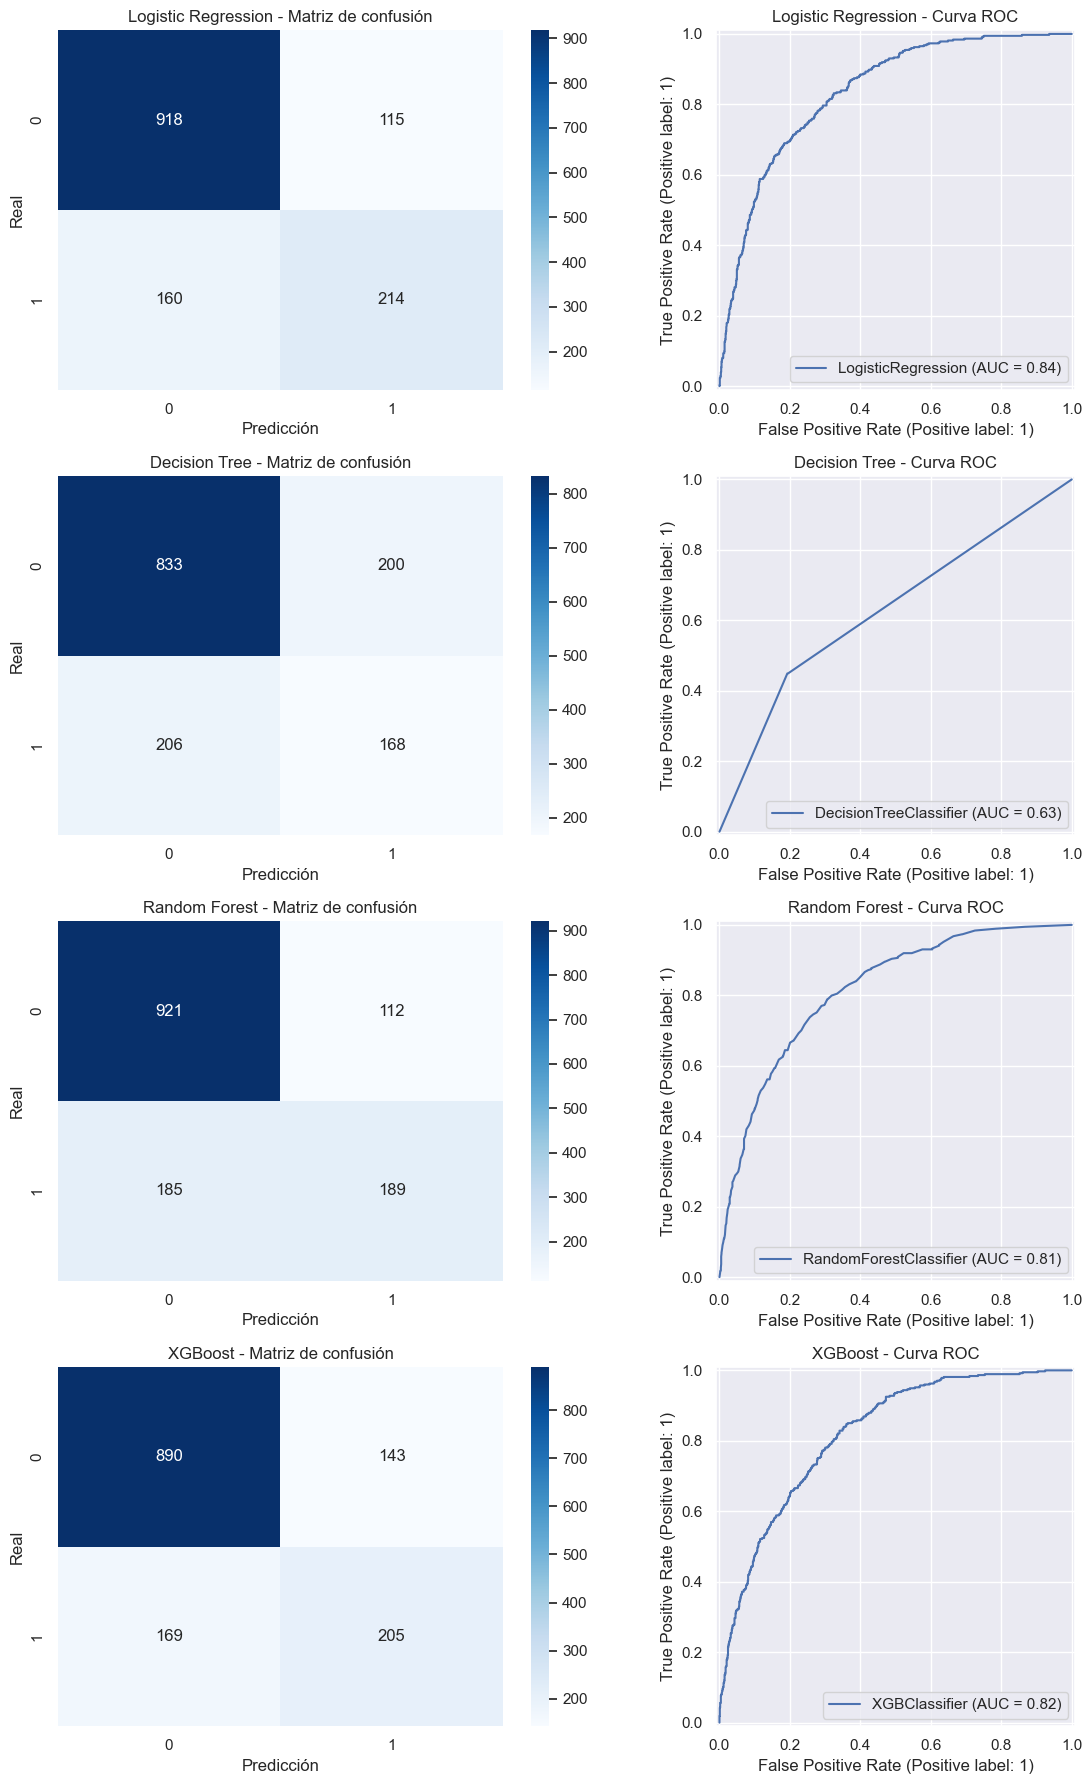

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(12, 18))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    # Predicciones
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Convertir a binario si es texto
    if y_test_series.dtype == 'O':
        y_true = (y_test_series == 'Yes').astype(int)
        y_pred_binary = (y_pred == 'Yes').astype(int)
    else:
        y_true = y_test_series
        y_pred_binary = y_pred

    # --- Matriz de confusión ---
    cm = confusion_matrix(y_true, y_pred_binary)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx * 2])
    axes[idx * 2].set_title(f"{name} - Matriz de confusión")
    axes[idx * 2].set_xlabel("Predicción")
    axes[idx * 2].set_ylabel("Real")

    # --- Curva ROC ---
    RocCurveDisplay.from_estimator(model, X_test, y_true, ax=axes[idx * 2 + 1])
    axes[idx * 2 + 1].set_title(f"{name} - Curva ROC")

plt.tight_layout()
plt.show()

## 🔧 Optimización de hiperparámetros

Vamos a aplicar una búsqueda de hiperparámetros con validación cruzada para exprimir el máximo rendimiento de los modelos más prometedores:
- **Logistic Regression**: ajuste del regularizador.
- **XGBoost**: ajuste de profundidad, tasa de aprendizaje y número de árboles.

In [7]:
#Cross-validation y Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# Definimos los modelos y sus hiperparámetros
param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Configuramos la validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
grid_log = GridSearchCV(log_model, param_grid_log, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_log.fit(X_train, y_train)
print("Best Logistic Regression Params:", grid_log.best_params_)
print("Best Logistic Regression ROC-AUC:", grid_log.best_score_)

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print("Best XGBoost Params:", grid_xgb.best_params_)
print("Best XGBoost ROC-AUC:", grid_xgb.best_score_)

Best Logistic Regression Params: {'C': 10, 'solver': 'saga'}
Best Logistic Regression ROC-AUC: 0.8462947516742652
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best XGBoost ROC-AUC: 0.8492574117113543


# 🔍 Comparación de Matrices de Confusión: Modelos Optimizados

Tras el ajuste de hiperparámetros mediante **Grid Search** y validación cruzada estratificada, analizaremos el **comportamiento real de los modelos optimizados** (Logistic Regression y XGBoost) sobre el conjunto de test.

El objetivo de esta comparación no es solo evaluar su *performance* global (ROC-AUC), sino entender **cómo se distribuyen sus aciertos y errores**:

| Métrica | Descripción |
|----------|--------------|
| ✅ **True Positive (TP)** | Clientes correctamente identificados como *churn* (predicción acertada de abandono). |
| ❌ **False Negative (FN)** | Clientes que abandonan pero el modelo no los detecta (error más costoso para el negocio). |
| ❌ **False Positive (FP)** | Clientes fieles clasificados erróneamente como *churn* (error menos grave, implica ofrecer incentivos innecesarios). |
| ✅ **True Negative (TN)** | Clientes correctamente identificados como no *churn*. |

Dado que en el sector telecomunicaciones **retener un cliente cuesta mucho menos que adquirir uno nuevo**, el **objetivo principal es minimizar los *False Negatives (FN)*** y maximizar el **Recall (Churn)**, incluso si esto implica un leve aumento en los *False Positives*.

A continuación, se compararán gráficamente las matrices de confusión de ambos modelos optimizados, junto con sus métricas clave (precision y recall para la clase *Churn*), con el fin de determinar **cuál modelo ofrece el mejor equilibrio entre retención y precisión operativa**.

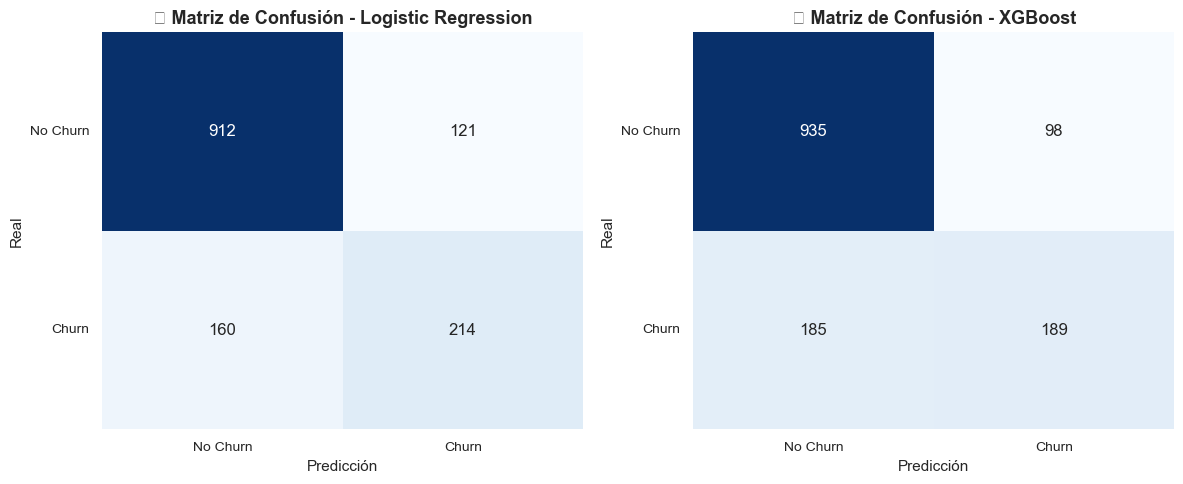


🔹 Comparativa de métricas principales:


,Model,Precision (Churn),Recall (Churn),F1-score (Churn),Accuracy
0,Logistic Regression,0.639,0.572,0.604,0.800
1,XGBoost,0.659,0.505,0.572,0.799


In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- Predicciones ---
y_pred_log = grid_log.best_estimator_.predict(X_test)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test)

# --- Matrices de confusión ---
cm_log = confusion_matrix(y_test, y_pred_log)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# --- Reportes de clasificación ---
report_log = classification_report(y_test, y_pred_log, output_dict=True, zero_division=0)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True, zero_division=0)

# --- Visualización lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, model_name in zip(axes, [cm_log, cm_xgb], ["Logistic Regression", "XGBoost"]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, annot_kws={"size": 12})
    ax.set_title(f"📊 Matriz de Confusión - {model_name}", fontsize=13, weight='bold')
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)
    ax.set_xticklabels(["No Churn", "Churn"], fontsize=10)
    ax.set_yticklabels(["No Churn", "Churn"], fontsize=10, rotation=0)

plt.tight_layout()
plt.show()

# --- Métricas comparativas ---
metrics = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Precision (Churn)': [report_log['1']['precision'], report_xgb['1']['precision']],
    'Recall (Churn)': [report_log['1']['recall'], report_xgb['1']['recall']],
    'F1-score (Churn)': [report_log['1']['f1-score'], report_xgb['1']['f1-score']],
    'Accuracy': [report_log['accuracy'], report_xgb['accuracy']]
})

print("\n🔹 Comparativa de métricas principales:")
display(metrics.round(3))

## 🧩 Comparación ajustada de Matrices de Confusión: Logistic Regression vs XGBoost

A continuación se muestran los valores extraídos de las matrices de confusión (test set) y las métricas calculadas:

### 🔹 Logistic Regression
- **True Negatives (TN):** 912
- **False Positives (FP):** 121
- **False Negatives (FN):** 160
- **True Positives (TP):** 214

Métricas (clase *Churn* = 1):
- **Precision:** 0.639
- **Recall:** 0.572
- **F1-score:** 0.604
- **Accuracy:** 0.800

### 🔹 XGBoost (optimizado)
- **True Negatives (TN):** 935
- **False Positives (FP):** 98
- **False Negatives (FN):** 185
- **True Positives (TP):** 189

Métricas (clase *Churn* = 1):
- **Precision:** 0.659
- **Recall:** 0.505
- **F1-score:** 0.572
- **Accuracy:** 0.799

---

### ⚖️ Interpretación y recomendación operativa

- **Logistic Regression** tiene **menos FNs** (160 vs 185) y **mejor Recall** (0.572 vs 0.505). También presenta **mejor F1-score** (0.604 vs 0.572) y una Accuracy prácticamente idéntica.
- En este contexto, donde **perder un cliente (FN)** suele costar más que un **falso positivo**, reducir los FN es prioritario.
- Por tanto, **Logistic Regression es la mejor opción actualmente**: detecta más churn reales y ofrece un mejor equilibrio entre precisión y sensibilidad.

## 🎯 Ajuste del Umbral de Decisión (Threshold Tuning)

En modelos de clasificación binaria como **Logistic Regression** y **XGBoost**, el modelo predice una probabilidad de pertenencia a la clase *churn*, no una etiqueta directa. Por defecto, se usa un umbral de 0.5 para decidir si un cliente es *churn* (1) o *no churn* (0), pero este valor puede ajustarse según el objetivo de negocio:

- **Maximizar Recall (detectar más churn):** bajar el umbral (ej. 0.35).
- **Maximizar Precision (evitar falsos positivos):** subir el umbral (ej. 0.65).

A continuación, se evalúan las métricas **Precision**, **Recall** y **F1-score** para distintos umbrales (de 0.1 a 0.9) y se visualiza cómo varían, permitiendo elegir el punto óptimo según la estrategia de retención de clientes.

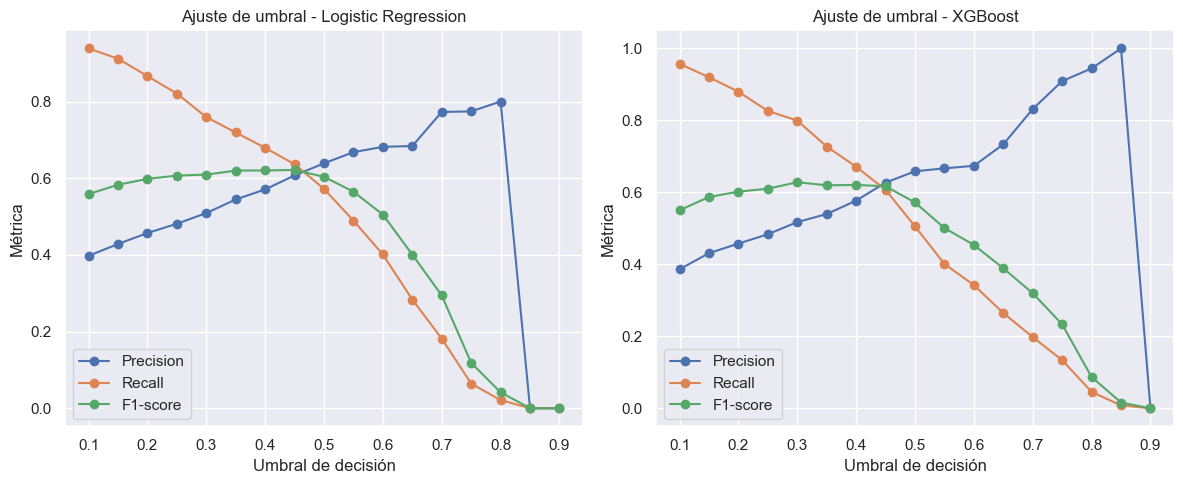

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Obtener probabilidades de predicción para la clase churn
probs_log = grid_log.best_estimator_.predict_proba(X_test)[:, 1]
probs_xgb = grid_xgb.best_estimator_.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)
metrics_log = {'threshold': [], 'precision': [], 'recall': [], 'f1': []}
metrics_xgb = {'threshold': [], 'precision': [], 'recall': [], 'f1': []}

for t in thresholds:
    # Logistic Regression
    preds_log = (probs_log >= t).astype(int)
    metrics_log['threshold'].append(t)
    metrics_log['precision'].append(precision_score(y_test, preds_log))
    metrics_log['recall'].append(recall_score(y_test, preds_log))
    metrics_log['f1'].append(f1_score(y_test, preds_log))
    # XGBoost
    preds_xgb = (probs_xgb >= t).astype(int)
    metrics_xgb['threshold'].append(t)
    metrics_xgb['precision'].append(precision_score(y_test, preds_xgb))
    metrics_xgb['recall'].append(recall_score(y_test, preds_xgb))
    metrics_xgb['f1'].append(f1_score(y_test, preds_xgb))

# Graficar resultados
plt.figure(figsize=(12, 5))
for i, (metrics, name) in enumerate(zip([metrics_log, metrics_xgb], ["Logistic Regression", "XGBoost"])):
    plt.subplot(1, 2, i+1)
    plt.plot(metrics['threshold'], metrics['precision'], label='Precision', marker='o')
    plt.plot(metrics['threshold'], metrics['recall'], label='Recall', marker='o')
    plt.plot(metrics['threshold'], metrics['f1'], label='F1-score', marker='o')
    plt.xlabel('Umbral de decisión')
    plt.ylabel('Métrica')
    plt.title(f'Ajuste de umbral - {name}')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# Ejemplo: seleccionar el threshold que maximiza el F1-score para Logistic Regression
best_idx = np.argmax(metrics_log['f1'])
best_threshold = metrics_log['threshold'][best_idx]
print(f"Mejor threshold (F1-score): {best_threshold:.2f}")

# Predicciones finales con el threshold óptimo
final_preds = (probs_log >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, final_preds)
print("Matriz de confusión:\n", cm)
print("\nReporte de clasificación:\n", classification_report(y_test, final_preds, digits=3))

Mejor threshold (F1-score): 0.45
Matriz de confusión:
 [[879 154]
 [136 238]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0      0.866     0.851     0.858      1033
           1      0.607     0.636     0.621       374

    accuracy                          0.794      1407
   macro avg      0.737     0.744     0.740      1407
weighted avg      0.797     0.794     0.795      1407



In [11]:
# Seleccionar el threshold que maximiza el F1-score para XGBoost
best_idx_xgb = np.argmax(metrics_xgb['f1'])
best_threshold_xgb = metrics_xgb['threshold'][best_idx_xgb]
print(f"Mejor threshold (F1-score) XGBoost: {best_threshold_xgb:.2f}")

# Predicciones finales con el threshold óptimo
final_preds_xgb = (probs_xgb >= best_threshold_xgb).astype(int)

# Matriz de confusión y reporte de clasificación
cm_xgb = confusion_matrix(y_test, final_preds_xgb)
print("Matriz de confusión XGBoost:\n", cm_xgb)
print("\nReporte de clasificación XGBoost:\n", classification_report(y_test, final_preds_xgb, digits=3))

Mejor threshold (F1-score) XGBoost: 0.30
Matriz de confusión XGBoost:
 [[754 279]
 [ 75 299]]

Reporte de clasificación XGBoost:
               precision    recall  f1-score   support

           0      0.910     0.730     0.810      1033
           1      0.517     0.799     0.628       374

    accuracy                          0.748      1407
   macro avg      0.713     0.765     0.719      1407
weighted avg      0.805     0.748     0.762      1407



## 📝 Reflexión sobre el ajuste de umbral y la comparación de modelos

La comparación entre **Logistic Regression** y **XGBoost** muestra que, aunque XGBoost puede alcanzar un mayor recall ajustando el umbral, esto se logra a costa de un aumento considerable en los falsos positivos, lo que puede traducirse en un mayor coste operativo. Por otro lado, Logistic Regression ofrece un mejor equilibrio entre precisión y recall, con menos falsos negativos y un F1-score competitivo.

La decisión final sobre qué modelo y umbral utilizar debe basarse en el impacto real de los errores para el negocio. Si la prioridad es **no perder clientes**, puede ser aceptable sacrificar precisión por un mayor recall. Si se busca un equilibrio y optimizar recursos, un modelo más conservador como Logistic Regression puede ser preferible.

## 🔍 Importancia de características (Feature Importance)

Analizaremos la importancia de las características para los modelos entrenados, especialmente para **Logistic Regression** y **XGBoost**, que proporcionan métricas de importancia de características de manera nativa. Esto nos ayudará a entender qué variables tienen mayor impacto en la predicción del churn y puede guiar futuras estrategias de retención de clientes.

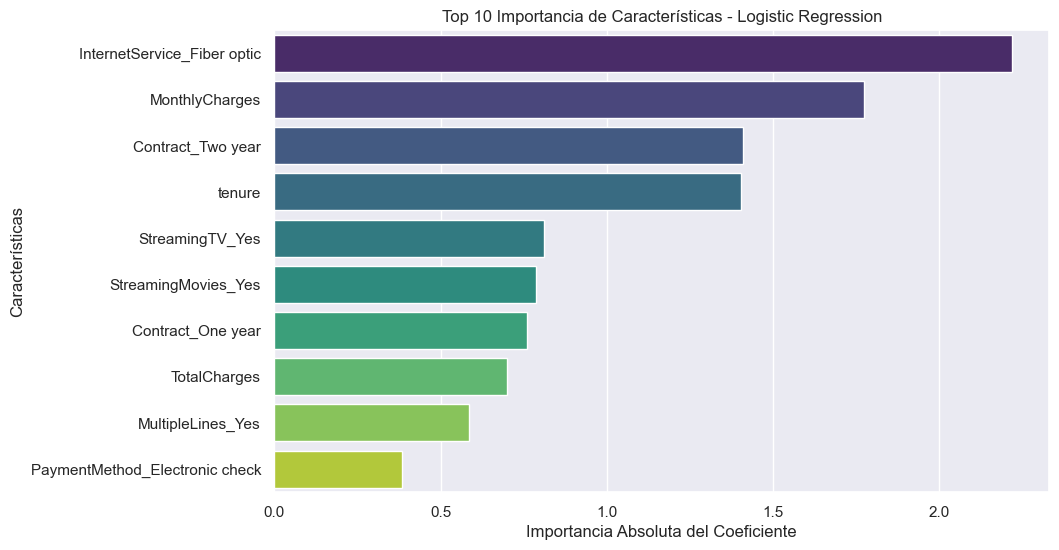

In [12]:
# Importancia de características para Logistic Regression

coef_log = grid_log.best_estimator_.coef_[0]
features_log = X_train.columns
importance_log = pd.DataFrame({'Feature': features_log, 'Importance': np.abs(coef_log)})
importance_log = importance_log.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_log.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Importancia de Características - Logistic Regression')
plt.xlabel('Importancia Absoluta del Coeficiente')
plt.ylabel('Características')
plt.show()

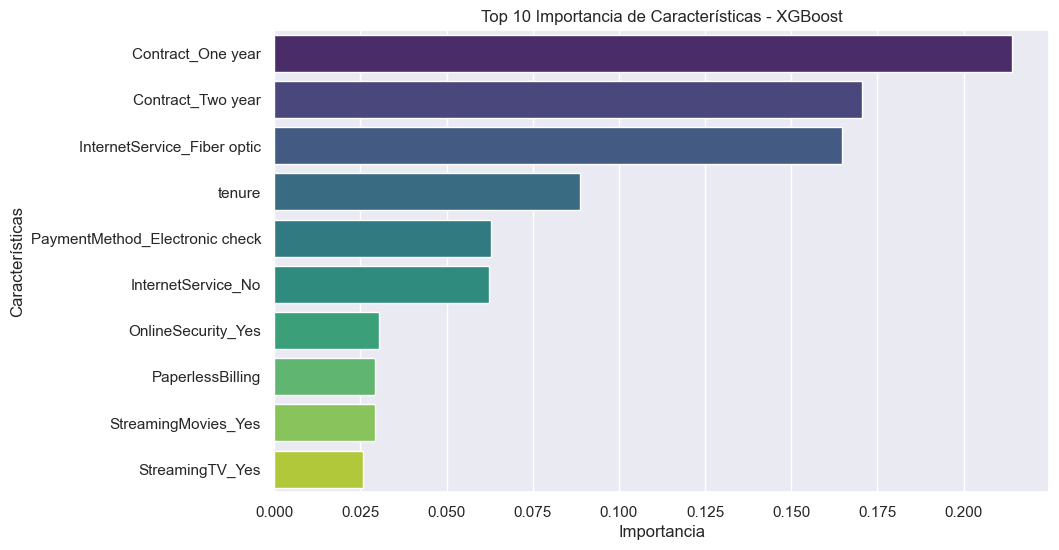

In [13]:
# Importancia de características para XGBoost
importance_xgb = grid_xgb.best_estimator_.feature_importances_
features_xgb = X_train.columns
importance_xgb_df = pd.DataFrame({'Feature': features_xgb, 'Importance': importance_xgb})
importance_xgb_df = importance_xgb_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_xgb_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Importancia de Características - XGBoost')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

## 🧪 Prueba con un cliente ficticio

Vamos a simular la predicción de churn para un cliente ficticio con las siguientes características:
- `feature_1`: valor_1
- `feature_2`: valor_2
- `feature_3`: valor_3
- ...
- `feature_n`: valor_n

A continuación, creamos un DataFrame con estos valores y utilizamos el modelo entrenado para predecir si este cliente es propenso a churn.

In [14]:
# --- 1. Crear los datos de los clientes ficticios ---
# Las columnas deben coincidir EXACTAMENTE con las del DataFrame original (antes de la división)
data = {
    'gender': ['Female', 'Male', 'Female', 'Male', 'Female'],
    'SeniorCitizen': [1, 0, 0, 0, 0],
    'Partner': ['No', 'No', 'No', 'Yes', 'Yes'],
    'Dependents': ['No', 'No', 'No', 'Yes', 'Yes'],
    'tenure': [1, 8, 12, 48, 72], # Desde 1 mes hasta 6 años
    'PhoneService': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes'],
    'MultipleLines': ['No', 'Yes', 'No', 'Yes', 'Yes'],
    'InternetService': ['Fiber optic', 'Fiber optic', 'Fiber optic', 'DSL', 'No'], # Espectro de servicios
    'OnlineSecurity': ['No', 'No', 'No', 'Yes', 'No internet service'],
    'OnlineBackup': ['No', 'No', 'Yes', 'Yes', 'No internet service'],
    'DeviceProtection': ['No', 'Yes', 'No', 'Yes', 'No internet service'],
    'TechSupport': ['No', 'No', 'No', 'Yes', 'No internet service'],
    'StreamingTV': ['No', 'Yes', 'Yes', 'Yes', 'No internet service'],
    'StreamingMovies': ['No', 'Yes', 'Yes', 'Yes', 'No internet service'],
    'Contract': ['Month-to-month', 'Month-to-month', 'One year', 'Two year', 'Two year'], # El factor clave
    'PaperlessBilling': ['Yes', 'Yes', 'Yes', 'No', 'No'],
    'PaymentMethod': ['Electronic check', 'Electronic check', 'Bank transfer (automatic)', 'Credit card (automatic)', 'Credit card (automatic)'],
    'MonthlyCharges': [70.70, 95.50, 90.00, 65.50, 25.75],
    'TotalCharges': [70.70, 764.00, 1080.00, 3144.00, 1854.00]
}

# --- 2. Crear un DataFrame con los datos ---
clientes_ficticios_df = pd.DataFrame(data)
print("--- Perfiles de Clientes a Predecir ---")
display(clientes_ficticios_df)

# --- 3. Preprocesar los datos (codificación y escalado) ---

# Codificación de variables categóricas
categorical_cols = clientes_ficticios_df.select_dtypes(include=['object']).columns
clientes_ficticios_encoded = pd.get_dummies(clientes_ficticios_df, columns=categorical_cols, drop_first=True)
# Asegurarse de que todas las columnas del conjunto de entrenamiento estén presentes
for col in X_train.columns:
    if col not in clientes_ficticios_encoded.columns:
        clientes_ficticios_encoded[col] = 0  # Añadir columna faltante con ceros
clientes_ficticios_encoded = clientes_ficticios_encoded[X_train.columns]  # Reordenar columnas

# Escalado de características numéricas
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
clientes_ficticios_encoded[numerical_cols] = scaler.fit_transform(clientes_ficticios_encoded[numerical_cols])

# --- 4. Realizar predicciones con el modelo optimizado ---
predicciones = grid_log.best_estimator_.predict(clientes_ficticios_encoded)
probabilidades = grid_log.best_estimator_.predict_proba(clientes_ficticios_encoded)

# --- 5. Mostrar resultados ---
for i, cliente in enumerate(data['gender']):  # Usamos 'gender' solo como identificador
    estado = 'Churn' if predicciones[i] == 1 else 'No Churn'
    prob_churn = probabilidades[i][1]
    print(f"Cliente {i+1} ({cliente}): Predicción = {estado}, Probabilidad de Churn = {prob_churn:.2f}")

--- Perfiles de Clientes a Predecir ---


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,70.7
1,Male,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.50,764.0
2,Female,0,No,No,12,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,One year,Yes,Bank transfer (automatic),90.00,1080.0
3,Male,0,Yes,Yes,48,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),65.50,3144.0
4,Female,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.75,1854.0


Cliente 1 (Female): Predicción = Churn, Probabilidad de Churn = 0.54
Cliente 2 (Male): Predicción = Churn, Probabilidad de Churn = 0.68
Cliente 3 (Female): Predicción = No Churn, Probabilidad de Churn = 0.31
Cliente 4 (Male): Predicción = No Churn, Probabilidad de Churn = 0.15
Cliente 5 (Female): Predicción = No Churn, Probabilidad de Churn = 0.01


Ordenando los clientes por riesgo, la empresa podría tomar acciones diferenciadas:

Cliente 2 (68%): 🔥 Alerta Roja. Intervención inmediata y personalizada.

Cliente 1 (54%): 🟠 Alerta Naranja. Incluir en una campaña de retención proactiva con una buena oferta.

Cliente 3 (31%): 🟡 Vigilancia. Monitorizar y contactar antes de la renovación.

Cliente 4 (15%): 🟢 Seguro. Campañas de fidelización o venta cruzada.

Cliente 5 (1%): ✅ Anclado. Cliente de bajo mantenimiento.

### 📌 Conclusiones y próximos pasos

- **Logistic Regression** se perfila como el modelo más equilibrado para predecir churn, con un buen balance entre precisión y recall.
- El ajuste del umbral de decisión permite adaptar el modelo a las prioridades del negocio, ya sea maximizar la retención o minimizar costos operativos.
- La importancia de características revela insights valiosos sobre qué factores influyen más en la pérdida de clientes.
- Los modelos pueden seguir mejorándose con técnicas avanzadas como ensamblado, ajuste fino de hiperparámetros y validación continua.
- En futuros pasos, se recomienda implementar un sistema de monitoreo para evaluar el rendimiento del modelo en producción y actualizarlo periódicamente con nuevos datos.
- Finalmente, se sugiere explorar modelos adicionales y técnicas de interpretación para garantizar decisiones informadas y efectivas en la estrategia de retención de clientes.